<a href="https://colab.research.google.com/github/debashisdotchatterjee/A-Lorentz-Mahalanobis-Distance-in-Minkowski-Space/blob/main/Real_Data_A_Lorentz_Mahalanobis_Distance_in_Minkowski_Space_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A clean downloadable Colab package, not a long fragile pasted block. The code will focus on a real physics dataset workflow: four-vector construction, LM fitting, score diagnostics, event ranking, robust comparison, boost-stability checks, and publication-ready figures/tables.

I will design the package so it does not depend on one fragile object layout. The code will try CMS Open Data first, extract jet-level (p
T
	​

,y,ϕ,m) robustly, construct (E,p
x
	​

,p
y
	​

,p
z
	​

), and then run a real-data LM analysis without repeating the simulation section.

Thought for 4m 7s

Yes — this time I made it properly as a downloadable Colab/Python package, not as a long uncopyable code wall.

(see github to download the code+readme)

It contains:

LM_RealData_Methodology_Colab.ipynb
lm_realdata_analysis_colab.py
README.txt
requirements.txt

The code is designed to use CMS Open Data jets through EnergyFlow MOD HDF5 as the primary dataset. EnergyFlow documents CMS2011AJets as a CMS Open Data jet collection with jet-level variables such as p
T
	​

, rapidity, ϕ, and mass, and the loader supports dataset='cms' and collection='CMS2011AJets'. The script converts these to physical four-vectors

(E,p
x
	​

,p
y
	​

,p
z
	​

),

then applies Lorentz--Mahalanobis methodology.

The package performs these real-data analyses:

Four-vector construction from jet data
Converts (p
T
	​

,y,ϕ,m) into (E,p
x
	​

,p
y
	​

,p
z
	​

), then checks the Minkowski interval.
Classical and robust LM model fitting
Fits classical covariance, MCD robust covariance, and Tyler shape versions.
Estimated rest-frame direction
Estimates
u
^
 spectrally from the ambient scatter/shape matrix.
Real-data LM scoring and ranking
Computes LM scores, robust LM scores, naive Euclidean scores, and Minkowski interval scores.
High-score jet profiling
Lists top robust-LM jets and compares top 1% high-score jets against the full sample.
Real-data boost-equivariance verification
Applies artificial Lorentz boosts to the observed real jet four-vectors and transports fitted parameters, checking that LM scores remain stable while naive coordinate scores change.
Central vs forward real-data two-sample LM test
Splits jets by ∣y∣, computes a Hotelling-type LM statistic in the adapted frame, and calibrates it by permutation.
Automatic output ZIP
Saves all figures, CSV tables, LaTeX tables, metadata, and a final ZIP.

In Colab, upload/extract the ZIP, open the notebook, and run:

results = run_realdata_analysis(CONFIG, make_zip=True)

# **How to run in Colab**
-------------------
1. Upload this ZIP to Colab and extract it, or upload the .ipynb directly.
2. Run the first notebook cell to install dependencies.
3. Run:

    results = run_realdata_analysis(CONFIG, make_zip=True)

In [6]:
!pip -q install energyflow scikit-learn h5py tables tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.2/503.2 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, bu

In [7]:
from pathlib import Path
import zipfile, sys, os

# If the ZIP is uploaded to /content, extract it
for z in Path("/content").glob("lm_realdata_methodology_package*.zip"):
    print("Extracting:", z)
    with zipfile.ZipFile(z, "r") as zf:
        zf.extractall("/content")

# Find the folder containing the script
possible_dirs = [
    Path("/content/lm_realdata_methodology_package"),
    Path("/content/lm_realdata_methodology_package_FIXED/lm_realdata_methodology_package"),
    Path.cwd(),
]

pkg_dir = None
for d in possible_dirs:
    if (d / "lm_realdata_analysis_colab.py").exists():
        pkg_dir = d
        break

if pkg_dir is None:
    raise FileNotFoundError("Could not find lm_realdata_analysis_colab.py. Please upload/extract the package ZIP first.")

sys.path.insert(0, str(pkg_dir))
os.chdir(str(pkg_dir))

from lm_realdata_analysis_colab import CONFIG, run_realdata_analysis

print("Imported successfully from:", pkg_dir)
print("Function available:", callable(run_realdata_analysis))

Extracting: /content/lm_realdata_methodology_package.zip
Imported successfully from: /content/lm_realdata_methodology_package
Function available: True


Starting Lorentz--Mahalanobis real-data methodology analysis.
This is not a simulation verification; it is a real/physics dataset workflow.
Configuration:
{
  "source": "cms_mod",
  "fallback_to_qg": true,
  "cms_amount": 1,
  "cms_cut": "corr_jet_pts > 400 & abs_jet_eta < 2.4",
  "cms_store_pfcs": false,
  "cms_validate_files": false,
  "qg_num_data": 60000,
  "qg_generator": "pythia",
  "qg_with_bc": false,
  "max_jets_analysis": 60000,
  "mcd_fit_max_n": 15000,
  "tyler_fit_max_n": 25000,
  "two_sample_max_per_group": 3500,
  "permutation_B": 999,
  "seed": 20260611,
  "outdir": "lm_realdata_outputs",
  "boost_etas": [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0
  ],
  "top_fraction": 0.01,
  "top_n_print": 25
}
Loading CMS Open Data jets through EnergyFlow MOD interface...
Important: amount=1 means one file; amount=1.0 means full dataset.
Loaded CMS_Jet300_pT375-infGeV in 29.545s
Loaded MODDataset with 69041 jets after cuts.
Saved table: lm_realdata_outputs/tables/table01_dataset_m

,actual_source,n_jets_used,pt_min,pt_max,rapidity_min,rapidity_max,mass_min,mass_max
0,cms_mod,60000,400.00069,30204.018483,-2.389698,2.392523,-0.000029,5811.129883



Dataset kinematic summary


,mean,sd,q05,q25,median,q75,q95,min,max,quantity
0,502.988056,420.566964,403.588854,420.576140,450.572596,506.935909,680.501582,4.000007e+02,3.020402e+04,pt
1,0.004306,0.891720,-1.441844,-0.674269,0.007822,0.673464,1.448963,-2.389698e+00,2.392523e+00,rapidity
2,0.739877,0.497751,0.064698,0.322041,0.673849,1.089262,1.646577,7.946628e-06,2.392523e+00,abs_rapidity
3,55.172903,71.336187,25.887485,37.015004,47.899168,63.951945,98.226976,-2.854658e-05,5.811130e+03,mass
4,737.779371,835.820603,427.145180,496.370374,608.513083,822.638379,1352.554998,4.009125e+02,8.892808e+04,E
5,8132.815937,321623.542812,670.161856,1370.110533,2294.330297,4089.851308,9648.538747,-6.984919e-10,3.376923e+07,m2_from_fourvector


Saved figure: lm_realdata_outputs/figures/fig01_realdata_kinematic_overview.png
Saved figure: lm_realdata_outputs/figures/fig01_realdata_kinematic_overview.pdf


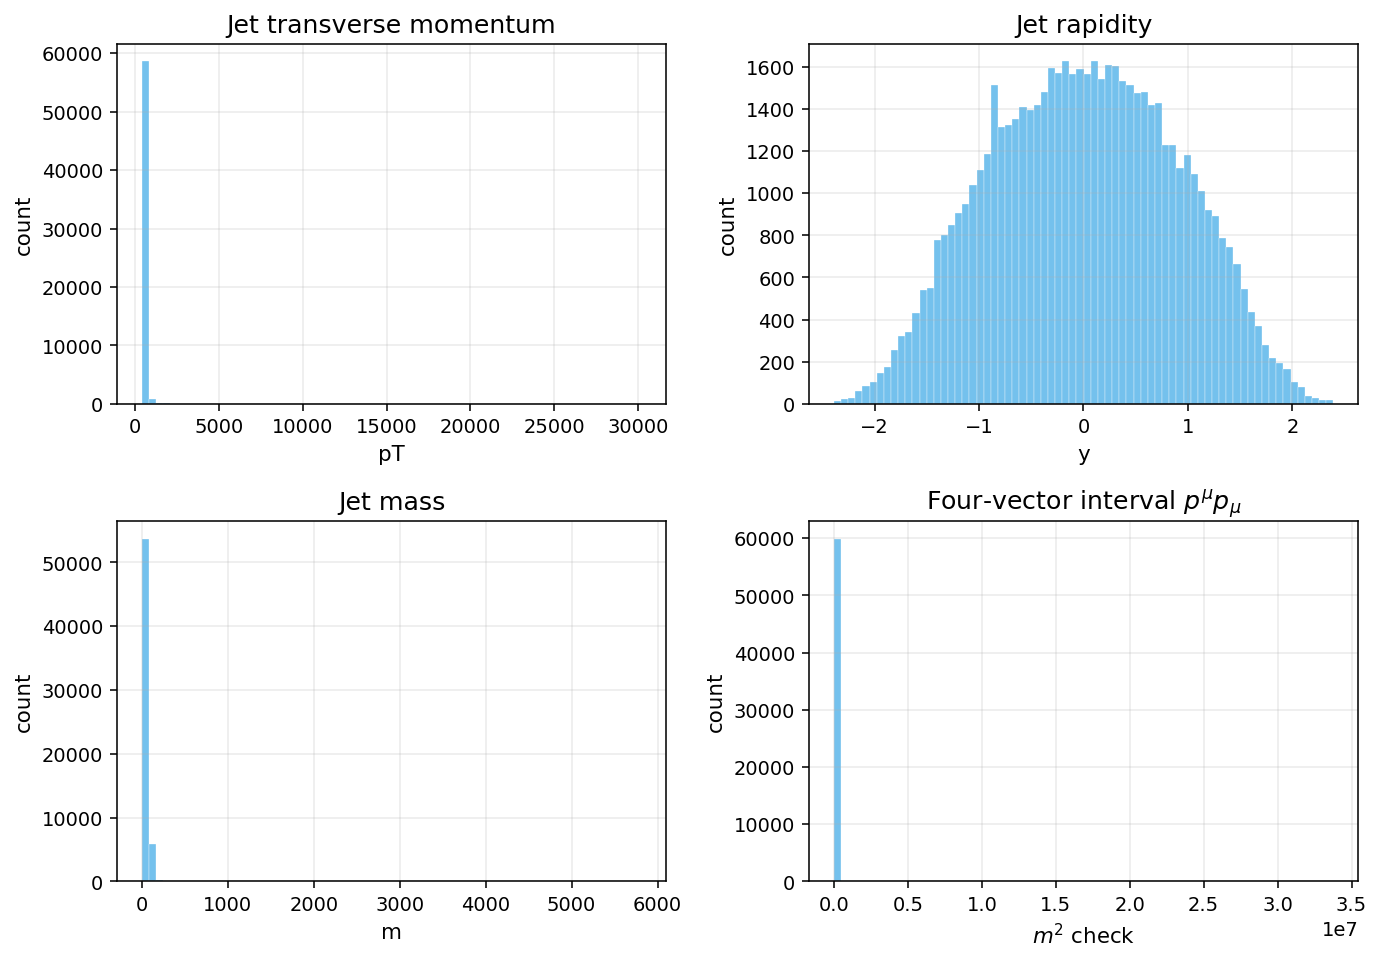


Fitting Lorentz--Mahalanobis models...
Saved table: lm_realdata_outputs/tables/table03_fitted_rest_frames.csv
Saved LaTeX: lm_realdata_outputs/tables/table03_fitted_rest_frames.tex

Fitted rest-frame and scatter summaries


,method,u0,u1,u2,u3,beta_norm,rapidity_norm,sigma_tau2,spatial_eig_min,spatial_eig_max,spatial_condition
0,Classical LM,1.040752,0.046174,-0.002195,-0.284655,0.277092,0.284529,595347.706416,145086.239790,784887.054510,5.409797
1,MCD robust LM,1.000171,0.006298,0.002052,-0.017285,0.018508,0.018510,12670.246183,108629.792410,114109.818621,1.050447
2,Tyler shape LM,1.000121,0.014769,0.000201,0.004813,0.015533,0.015534,0.270255,1.129764,1.421072,1.257849


Saved table: lm_realdata_outputs/tables/table04_score_quantiles.csv
Saved LaTeX: lm_realdata_outputs/tables/table04_score_quantiles.tex

Score distribution summaries


,mean,sd,q05,q25,median,q75,q95,min,max,score,q99,q995
0,4.000000e+00,9.564565e+01,0.891922,1.273265,1.662149,2.426880,5.998002e+00,0.564575,1.441508e+04,Classical LM,1.554950e+01,2.746046e+01
1,6.727022e+01,4.252003e+03,2.586900,2.803460,3.515266,11.043873,6.469440e+01,2.365875,6.670673e+05,MCD robust LM,2.027438e+02,4.608171e+02
2,3.590700e+06,2.240563e+08,258209.833085,273524.486760,307797.608885,666749.190984,3.312522e+06,241756.890668,3.516583e+10,Tyler shape LM,1.031112e+07,2.283129e+07
3,4.000000e+00,1.552218e+02,0.919119,1.051437,1.270766,1.788934,4.052407e+00,0.807655,2.407674e+04,Naive Euclidean,1.034777e+01,2.496639e+01
4,5.363500e+05,1.167877e+06,83665.458335,185796.586664,350482.260065,665369.803791,1.444780e+06,33932.103016,1.299660e+08,Minkowski interval,2.425746e+06,3.502751e+06


Saved figure: lm_realdata_outputs/figures/fig02_realdata_score_histograms.png
Saved figure: lm_realdata_outputs/figures/fig02_realdata_score_histograms.pdf


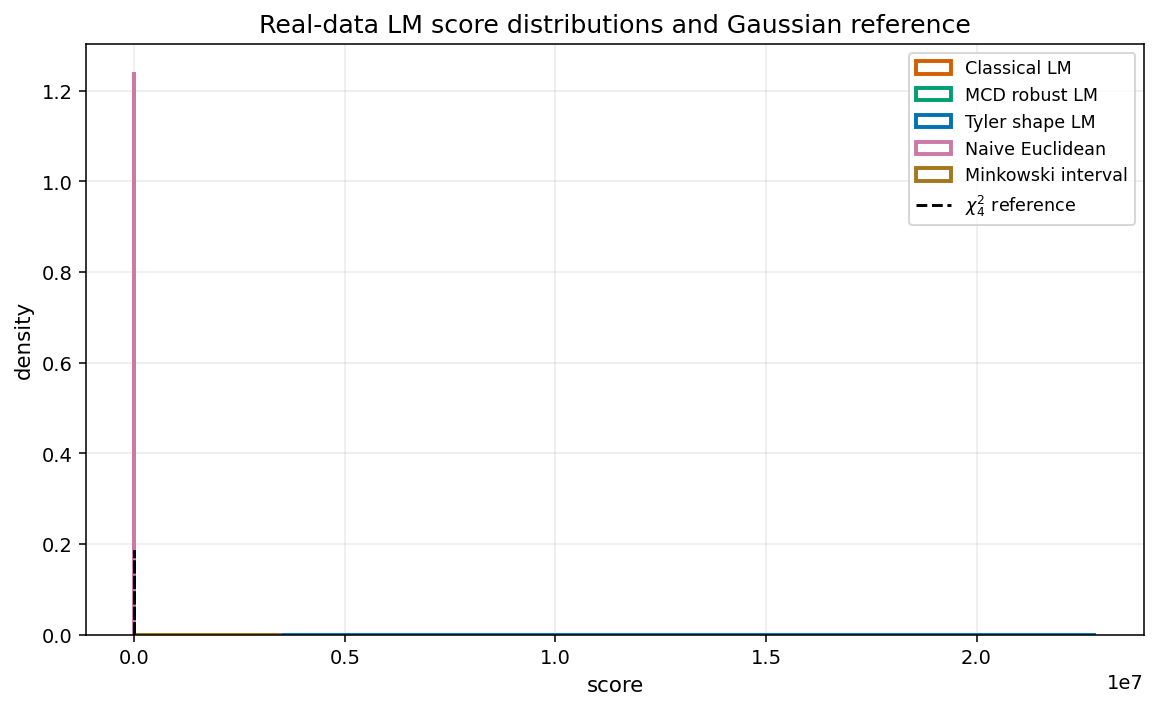

Saved figure: lm_realdata_outputs/figures/fig03_realdata_temporal_spatial_decomposition.png
Saved figure: lm_realdata_outputs/figures/fig03_realdata_temporal_spatial_decomposition.pdf


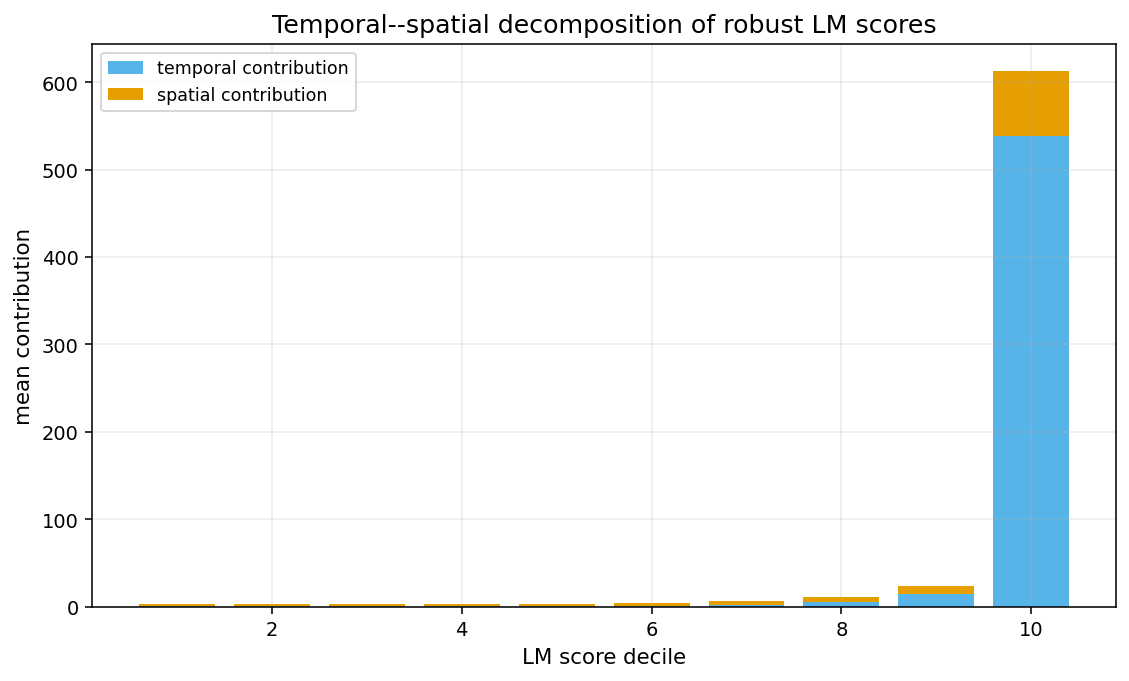

Saved table: lm_realdata_outputs/tables/table05_temporal_spatial_deciles.csv
Saved LaTeX: lm_realdata_outputs/tables/table05_temporal_spatial_deciles.tex

Temporal--spatial score contribution by robust LM decile


,decile,temporal,spatial
0,1,0.295326,2.282065
1,2,0.355942,2.324962
2,3,0.515076,2.291534
3,4,0.767125,2.245494
4,5,1.014562,2.295411
5,6,0.623489,3.454745
6,7,1.760663,4.586073
7,8,5.212161,6.068738
8,9,14.469801,8.838552
9,10,538.713721,74.586800


/content/lm_realdata_methodology_package/lm_realdata_analysis_colab.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure: lm_realdata_outputs/figures/fig04_realdata_lm_score_vs_kinematics.png
Saved figure: lm_realdata_outputs/figures/fig04_realdata_lm_score_vs_kinematics.pdf


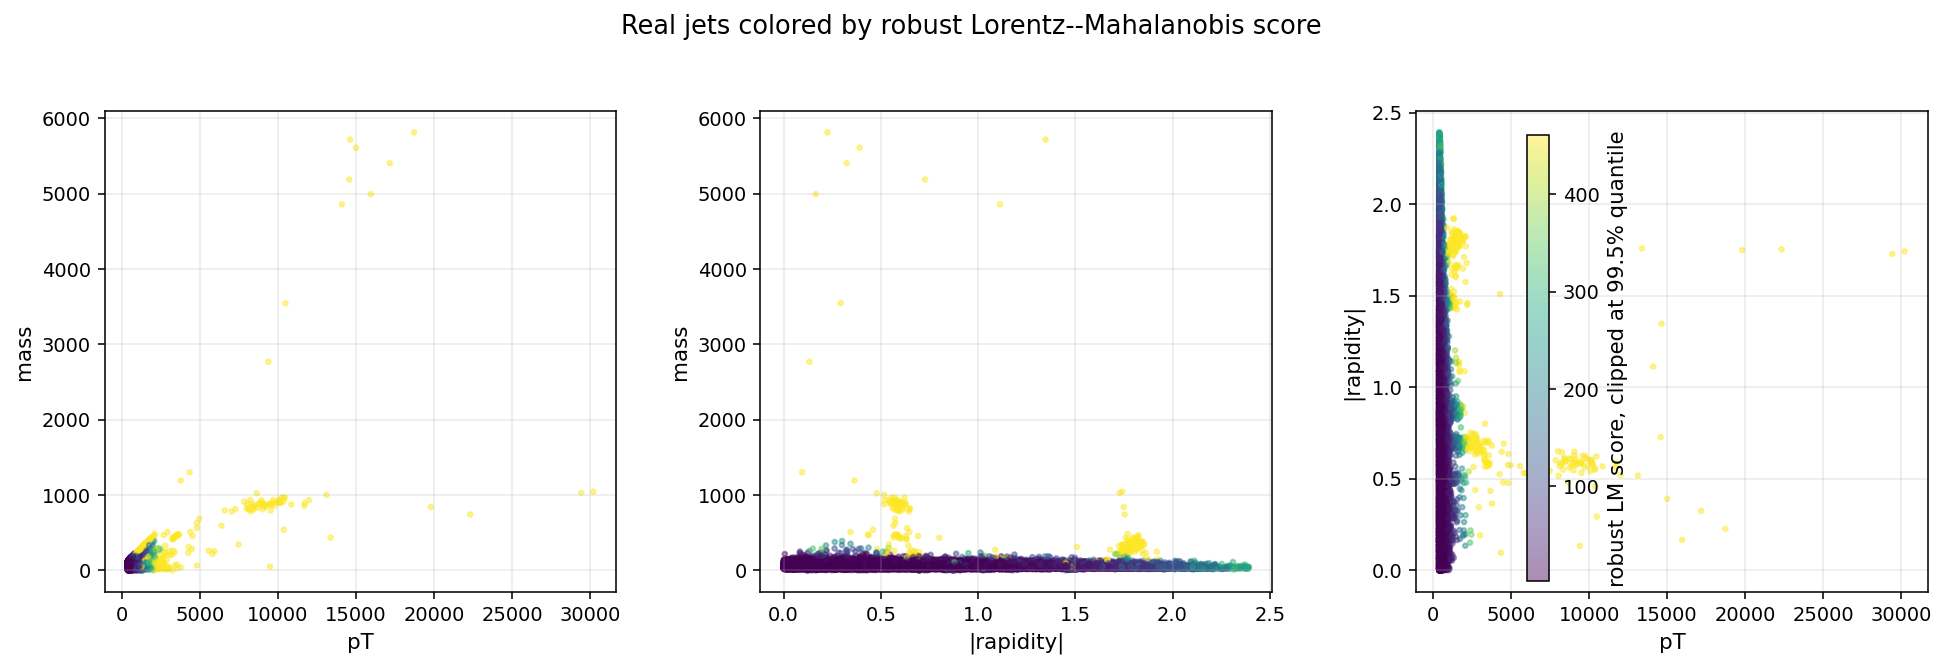

Saved figure: lm_realdata_outputs/figures/fig05_realdata_robust_vs_classical.png
Saved figure: lm_realdata_outputs/figures/fig05_realdata_robust_vs_classical.pdf


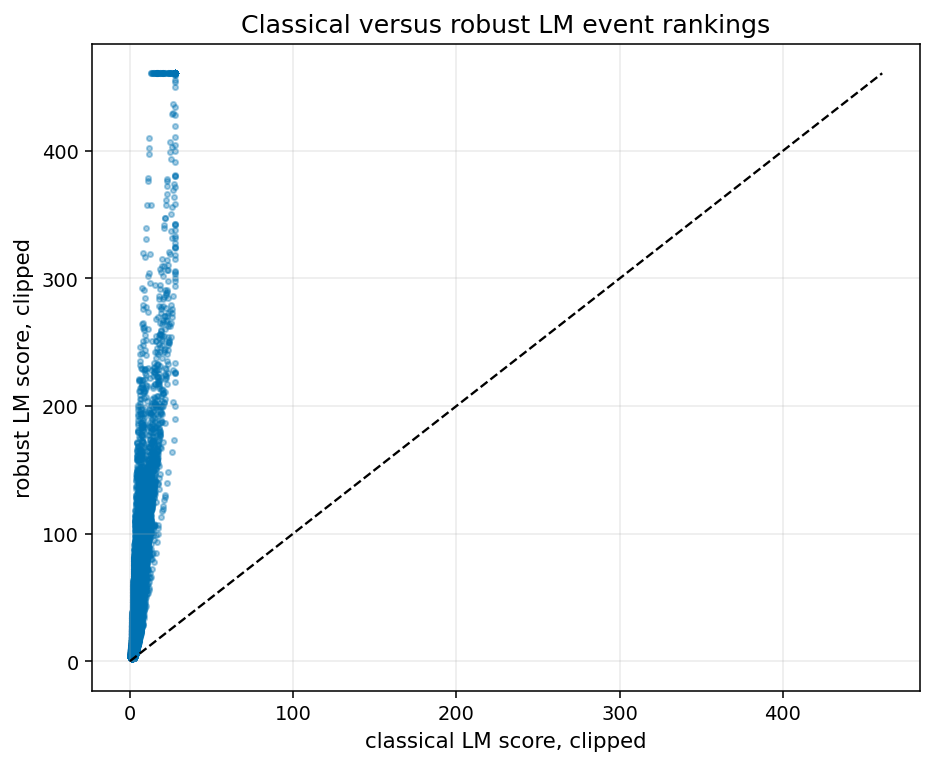

Saved table: lm_realdata_outputs/tables/table06_top_robust_lm_jets.csv
Saved LaTeX: lm_realdata_outputs/tables/table06_top_robust_lm_jets.tex

Top 25 jets by MCD robust LM


,jet_index,pt,rapidity,phi,mass,E,m2_from_fourvector,npv,quality,Classical LM,MCD robust LM,Tyler shape LM,Naive Euclidean,Minkowski interval
0,39447,30204.018483,-1.742193,3.909793,1042.499512,88928.081085,1.086805e+06,8,0,14415.082848,667067.262407,3.516583e+10,24076.740468,1.299660e+08
1,2714,29431.032655,-1.728302,3.915586,1027.647095,85529.706976,1.056059e+06,9,0,13363.090836,616825.318774,3.251948e+10,22343.287519,1.249762e+08
2,58267,22327.257188,-1.753821,3.927169,740.164123,66457.205677,5.478429e+05,1,0,7991.587726,371025.339420,1.955717e+10,13378.041669,9.723697e+07
3,2908,19810.137502,-1.749145,3.924427,839.679260,58726.436592,7.050613e+05,6,0,6235.733756,289132.750824,1.524123e+10,10442.664405,8.564501e+07
4,29963,13385.378151,-1.758466,3.926475,432.722107,40015.301394,1.872484e+05,1,0,2868.251820,133114.994446,7.016996e+09,4812.252305,5.847303e+07
5,59463,14635.203795,-1.347242,4.068648,5716.909668,32263.043843,3.268306e+07,1,0,2066.263219,85978.356053,4.528567e+09,3422.831742,1.458388e+07
6,57725,14103.437577,-1.112850,5.824109,4855.634766,25145.518278,2.357719e+07,6,0,2202.352561,51447.711031,2.676282e+09,2262.154445,1.246412e+07
7,44001,18726.268031,0.225751,1.912011,5811.129883,20108.952371,3.376923e+07,1,0,3195.860196,33793.805062,1.741273e+09,2256.933727,4.501939e+06
8,14906,14577.279722,-0.727467,5.742589,5185.493164,19749.872457,2.688934e+07,1,0,1820.393790,31453.448042,1.630364e+09,1672.834207,1.249583e+06
9,25754,17174.413545,0.324554,1.630462,5402.820312,18960.781804,2.919047e+07,1,0,2465.869326,29917.169100,1.525243e+09,1958.046384,1.786321e+06


Saved table: lm_realdata_outputs/tables/table07_high_score_profile.csv
Saved LaTeX: lm_realdata_outputs/tables/table07_high_score_profile.tex

High-score jet profile: top fraction versus full sample


,score_used,top_fraction,score_cutoff,quantity,full_median,top1pct_median,full_q95,top1pct_q95,median_ratio_top_to_full
0,MCD robust LM,0.01,202.743845,pt,450.572596,1493.939593,680.501582,9786.627417,3.315647
1,MCD robust LM,0.01,202.743845,abs_rapidity,0.673849,1.499086,1.646577,2.324641,2.224663
2,MCD robust LM,0.01,202.743845,mass,47.899168,103.353420,98.226976,898.849640,2.157729
3,MCD robust LM,0.01,202.743845,E,608.513083,2795.930112,1352.554998,11574.022200,4.594692
4,MCD robust LM,0.01,202.743845,npv,6.000000,5.000000,11.000000,10.000000,0.833333


Saved figure: lm_realdata_outputs/figures/fig08_realdata_top_outlier_map.png
Saved figure: lm_realdata_outputs/figures/fig08_realdata_top_outlier_map.pdf


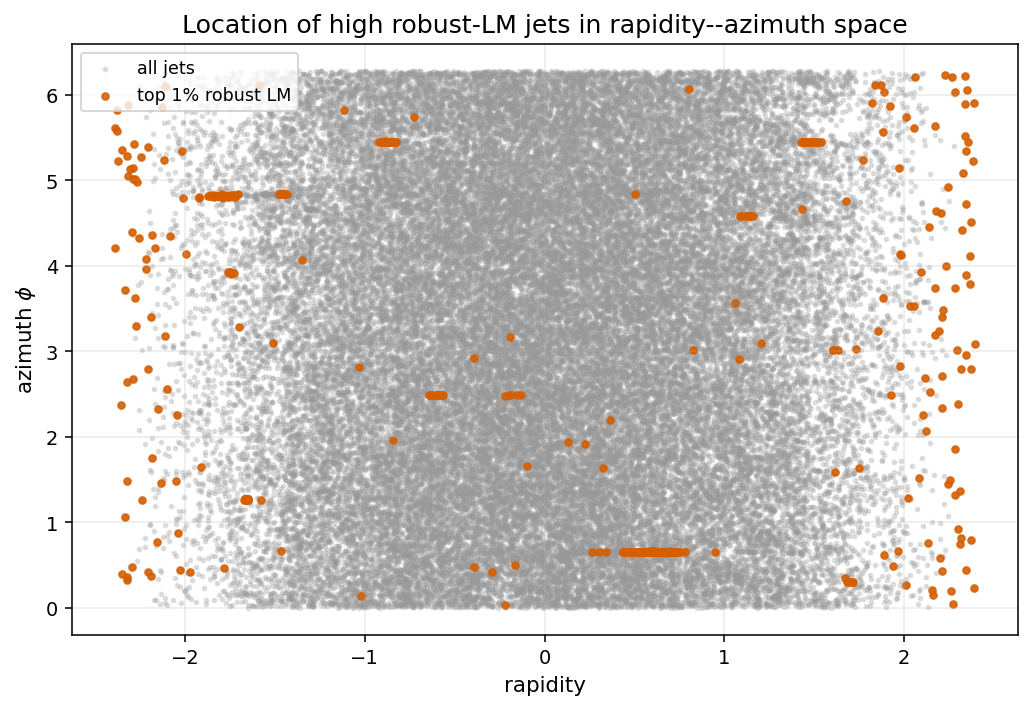


Running real-data parameter-transport equivariance check...
Saved table: lm_realdata_outputs/tables/table08_boost_equivariance_realdata.csv
Saved LaTeX: lm_realdata_outputs/tables/table08_boost_equivariance_realdata.tex

Real-data boost equivariance table


,eta,score,mean_abs_change,median_abs_change,q95_abs_change,max_abs_change
0,0.0,Classical LM,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.0,MCD robust LM,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,0.0,Tyler shape LM,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,0.0,Naive Euclidean,1.997451e-14,9.103829e-15,2.575717e-14,1.236913e-10
4,0.0,Minkowski interval,1.585530e-09,1.280569e-09,3.725290e-09,2.384186e-07
5,0.5,Classical LM,1.025293e-15,4.440892e-16,1.776357e-15,5.456968e-12
6,0.5,MCD robust LM,1.654487e-14,8.881784e-16,1.421085e-14,1.746230e-10
7,0.5,Tyler shape LM,1.190343e-09,1.164153e-10,9.313226e-10,1.525879e-05
8,0.5,Naive Euclidean,8.984888e-01,1.935673e-01,9.019307e-01,4.079408e+03
9,0.5,Minkowski interval,3.668992e-09,3.346941e-09,6.519258e-09,2.861023e-06


Saved figure: lm_realdata_outputs/figures/fig06_realdata_boost_equivariance.png
Saved figure: lm_realdata_outputs/figures/fig06_realdata_boost_equivariance.pdf


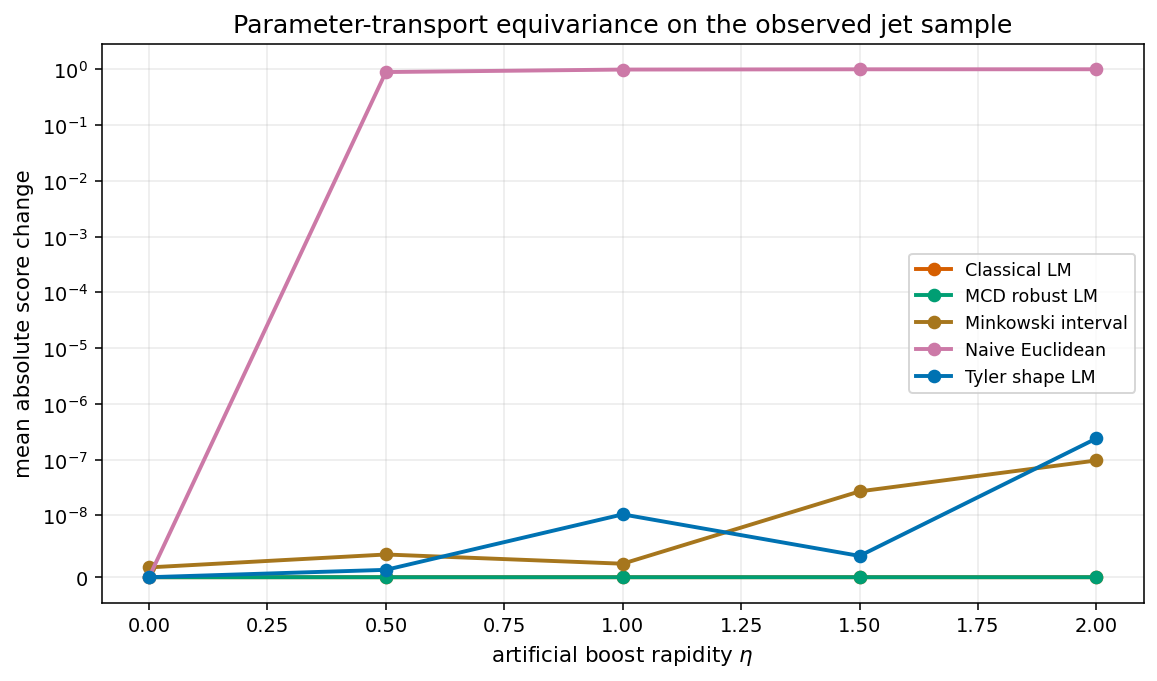


Running real-data central-vs-forward two-sample LM test...
Saved table: lm_realdata_outputs/tables/table09_two_sample_central_forward.csv
Saved LaTeX: lm_realdata_outputs/tables/table09_two_sample_central_forward.tex

Two-sample LM test: central versus forward jets


,comparison,group0,group1,n_group0,n_group1,T2,F_statistic,F_approx_pvalue,permutation_pvalue,LM_mean_separation
0,central vs forward jets,|rapidity| <= median (0.6738),|rapidity| > median (0.6738),3500,3500,322.261325,80.530793,1.110223e-16,0.001,0.184149


Saved figure: lm_realdata_outputs/figures/fig07_realdata_two_sample_permutation.png
Saved figure: lm_realdata_outputs/figures/fig07_realdata_two_sample_permutation.pdf


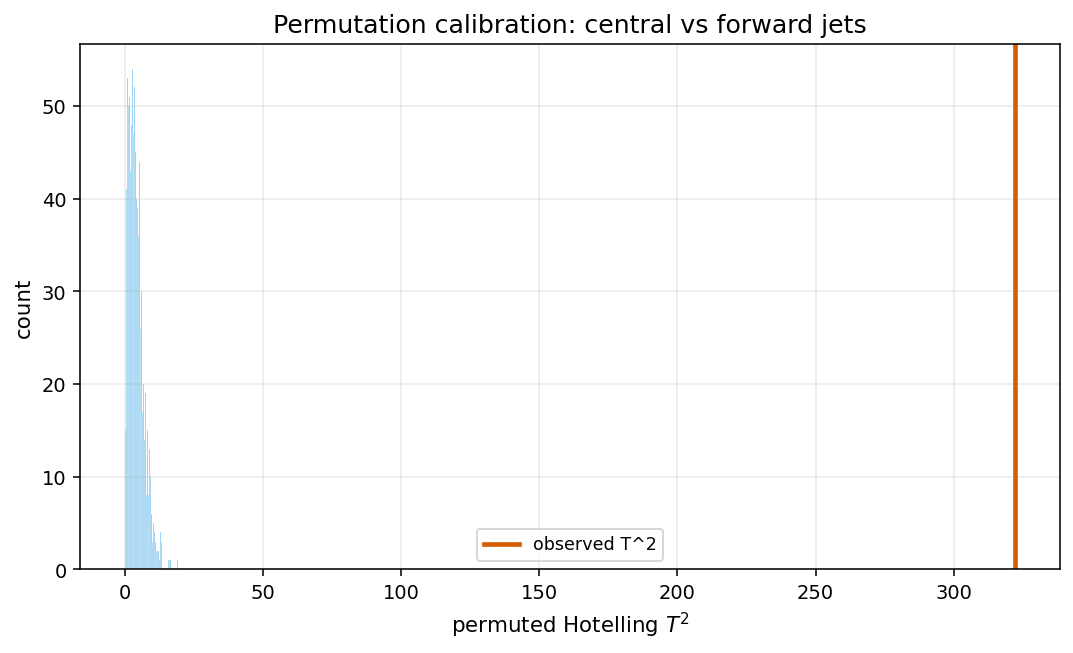


Created ZIP archive: /content/lm_realdata_methodology_package/lm_realdata_outputs.zip
Attempting Colab download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
   results = run_realdata_analysis(CONFIG, make_zip=True)

# **A Better,Cleaner Real Data Workflow**

Starting CLEAN Lorentz--Mahalanobis real-data analysis.
This version suppresses non-informative outputs and keeps only manuscript-useful diagnostics.
{
  "source": "cms_mod",
  "fallback_to_qg": true,
  "cms_amount": 1,
  "cms_cut": "corr_jet_pts > 400 & abs_jet_eta < 2.4",
  "cms_store_pfcs": false,
  "cms_validate_files": false,
  "qg_num_data": 60000,
  "qg_generator": "pythia",
  "qg_with_bc": false,
  "max_jets_analysis": 60000,
  "mcd_fit_max_n": 15000,
  "tyler_fit_max_n": 25000,
  "two_sample_max_per_group": 3500,
  "permutation_B": 999,
  "seed": 20260611,
  "outdir": "lm_realdata_clean_outputs",
  "boost_etas": [
    0.0,
    0.5,
    1.0,
    1.5,
    2.0
  ],
  "top_fraction": 0.01,
  "top_n_print": 15
}
Loading CMS Open Data jets through EnergyFlow MOD interface...
Important: amount=1 means one file; amount=1.0 means full dataset.
Loaded CMS_Jet300_pT375-infGeV in 0.127s
Loaded MODDataset with 69041 jets after cuts.
Saved: lm_realdata_clean_outputs/tables/table01_source_me

,actual_source,n_jets_used,pt_min,pt_max,rapidity_min,rapidity_max,mass_min,mass_max,median_abs_fourvector_mass_error
0,cms_mod,60000,400.00069,30204.018483,-2.389698,2.392523,-0.000029,5811.129883,5.638867e-11



Table 2: compact kinematic summary


,quantity,median,q75,q90,q95,q99,max
0,$p_T$,450.572596,506.935909,594.827638,680.501582,1136.423467,30204.018483
1,$|y|$,0.673849,1.089262,1.444924,1.646577,1.981437,2.392523
2,mass,47.899168,63.951945,83.915623,98.226976,136.805069,5811.129883
3,energy,608.513083,822.638379,1119.859673,1352.554998,2025.227716,88928.081085
4,NPV,6.000000,8.000000,9.000000,11.000000,13.000000,20.000000


Saved: lm_realdata_clean_outputs/figures/fig01_realdata_clean_kinematics.png
Saved: lm_realdata_clean_outputs/figures/fig01_realdata_clean_kinematics.pdf


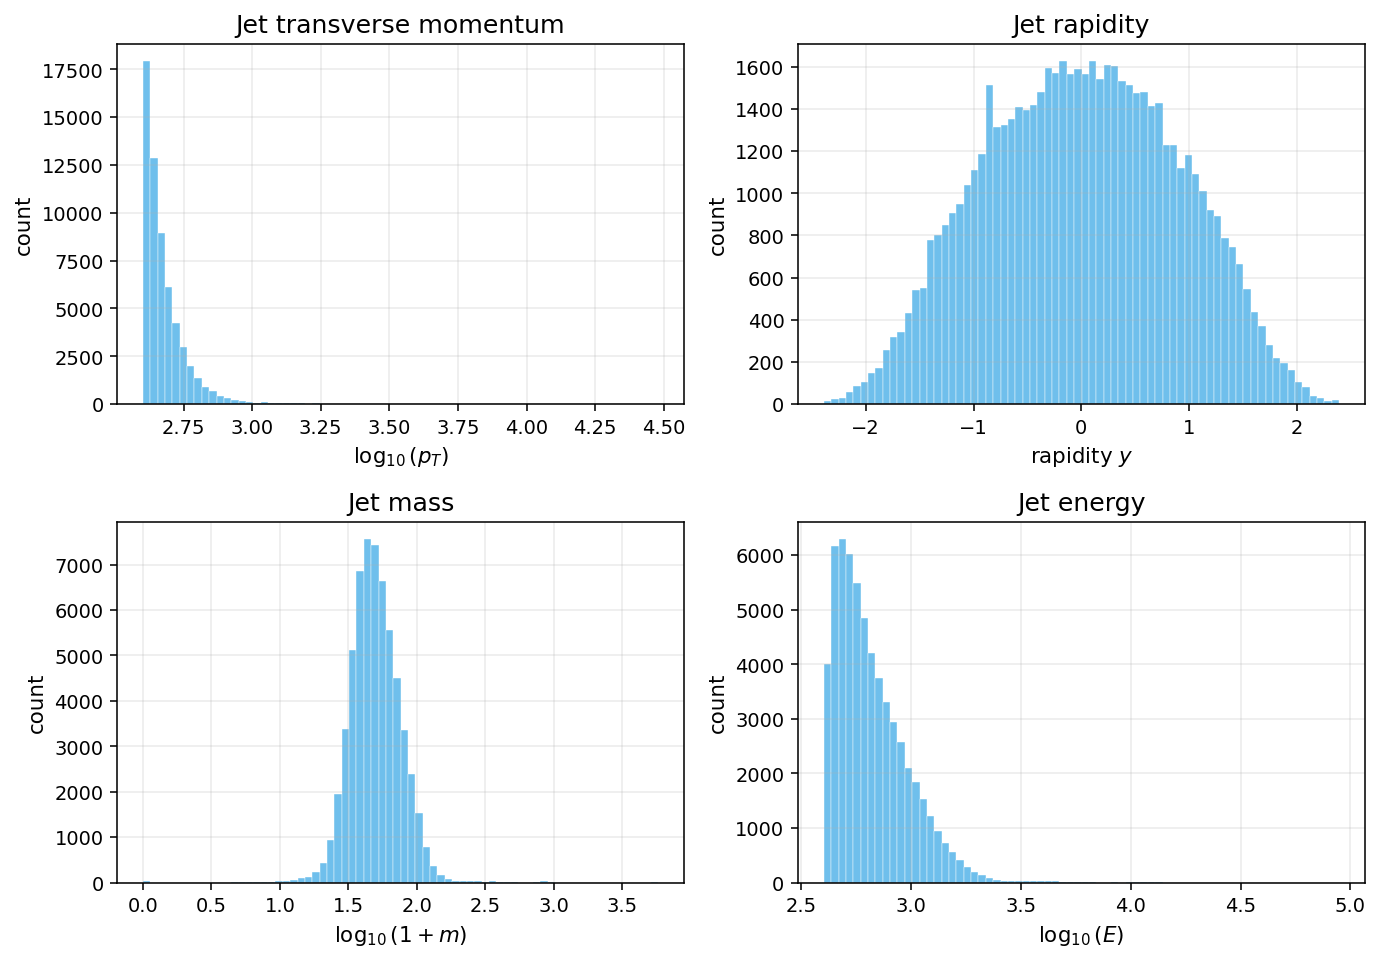

Saved: lm_realdata_clean_outputs/tables/table03_fitted_lm_models.csv
Saved: lm_realdata_clean_outputs/tables/table03_fitted_lm_models.tex

Table 3: fitted Lorentz--Mahalanobis rest-frame models


,method,u0,u1,u2,u3,beta_norm,rapidity_norm,sigma_tau2,spatial_condition
0,Classical LM,1.040752,0.046174,-0.002195,-0.284655,0.277092,0.284529,595347.706416,5.409797
1,MCD robust LM,1.000171,0.006298,0.002052,-0.017285,0.018508,0.018510,12670.246183,1.050447


Saved: lm_realdata_clean_outputs/tables/table04_score_tail_summary.csv
Saved: lm_realdata_clean_outputs/tables/table04_score_tail_summary.tex

Table 4: interpretable score-tail summary


,score,median,q75,q90,q95,q99,max
0,Classical LM,1.662149,2.426880,4.040520e+00,5.998002e+00,1.554950e+01,1.441508e+04
1,MCD robust LM,3.515266,11.043873,3.503162e+01,6.469440e+01,2.027438e+02,6.670673e+05
2,Naive Euclidean,1.270766,1.788934,2.846388e+00,4.052407e+00,1.034777e+01,2.407674e+04
3,Minkowski interval,350482.260065,665369.803791,1.103930e+06,1.444780e+06,2.425746e+06,1.299660e+08


Saved: lm_realdata_clean_outputs/figures/fig02_realdata_clean_score_tails.png
Saved: lm_realdata_clean_outputs/figures/fig02_realdata_clean_score_tails.pdf


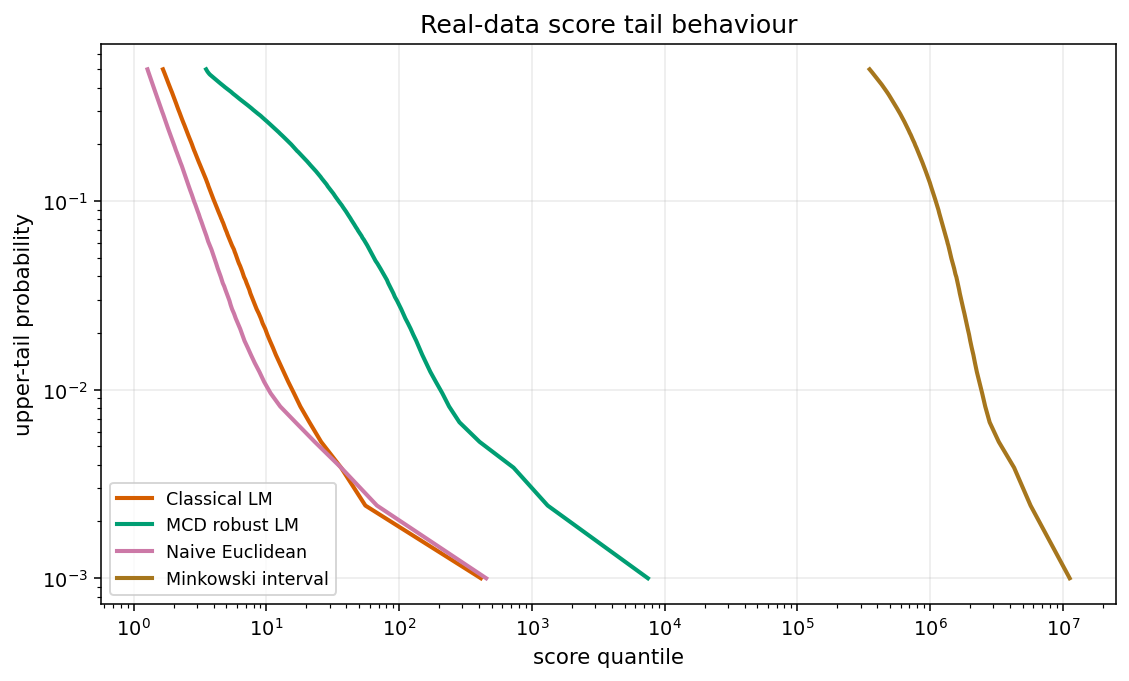

Saved: lm_realdata_clean_outputs/tables/table05_high_score_profile.csv
Saved: lm_realdata_clean_outputs/tables/table05_high_score_profile.tex

Table 5: high robust-LM score profile


,score_used,top_fraction,score_cutoff,quantity,full_median,top1pct_median,median_ratio_top_to_full,full_q95,top1pct_q95
0,MCD robust LM,0.01,202.743845,pt,450.572596,1493.939593,3.315647,680.501582,9786.627417
1,MCD robust LM,0.01,202.743845,abs_rapidity,0.673849,1.499086,2.224663,1.646577,2.324641
2,MCD robust LM,0.01,202.743845,mass,47.899168,103.353420,2.157729,98.226976,898.849640
3,MCD robust LM,0.01,202.743845,E,608.513083,2795.930112,4.594692,1352.554998,11574.022200
4,MCD robust LM,0.01,202.743845,npv,6.000000,5.000000,0.833333,11.000000,10.000000
5,MCD robust LM,0.01,202.743845,temporal_fraction_of_score,0.301866,0.849317,2.813558,0.746996,0.891160


Saved: lm_realdata_clean_outputs/tables/table06_top_robust_lm_jets.csv
Saved: lm_realdata_clean_outputs/tables/table06_top_robust_lm_jets.tex

Table 6: top 15 jets by MCD robust LM


,jet_index,pt,rapidity,mass,E,npv,quality,robust_LM_score,temporal_component,spatial_component,temporal_fraction
39447,39447,30204.018483,-1.742193,1042.499512,88928.081085,8,0,667067.262407,598859.873877,68207.388530,0.897750
2714,2714,29431.032655,-1.728302,1027.647095,85529.706976,9,0,616825.318774,553730.863388,63094.455386,0.897711
58267,58267,22327.257188,-1.753821,740.164123,66457.205677,1,0,371025.339420,332929.221438,38096.117982,0.897322
2908,2908,19810.137502,-1.749145,839.679260,58726.436592,6,0,289132.750824,259387.207160,29745.543664,0.897122
29963,29963,13385.378151,-1.758466,432.722107,40015.301394,1,0,133114.994446,119303.104573,13811.889873,0.896241
59463,59463,14635.203795,-1.347242,5716.909668,32263.043843,1,0,85978.356053,77276.212479,8702.143574,0.898787
57725,57725,14103.437577,-1.112850,4855.634766,25145.518278,6,0,51447.711031,46080.336937,5367.374094,0.895673
44001,44001,18726.268031,0.225751,5811.129883,20108.952371,1,0,33793.805062,30390.042372,3403.762690,0.899279
14906,14906,14577.279722,-0.727467,5185.493164,19749.872457,1,0,31453.448042,28215.583922,3237.864120,0.897059
25754,25754,17174.413545,0.324554,5402.820312,18960.781804,1,0,29917.169100,26918.578119,2998.590981,0.899770


Saved: lm_realdata_clean_outputs/figures/fig03_realdata_clean_high_score_map.png
Saved: lm_realdata_clean_outputs/figures/fig03_realdata_clean_high_score_map.pdf


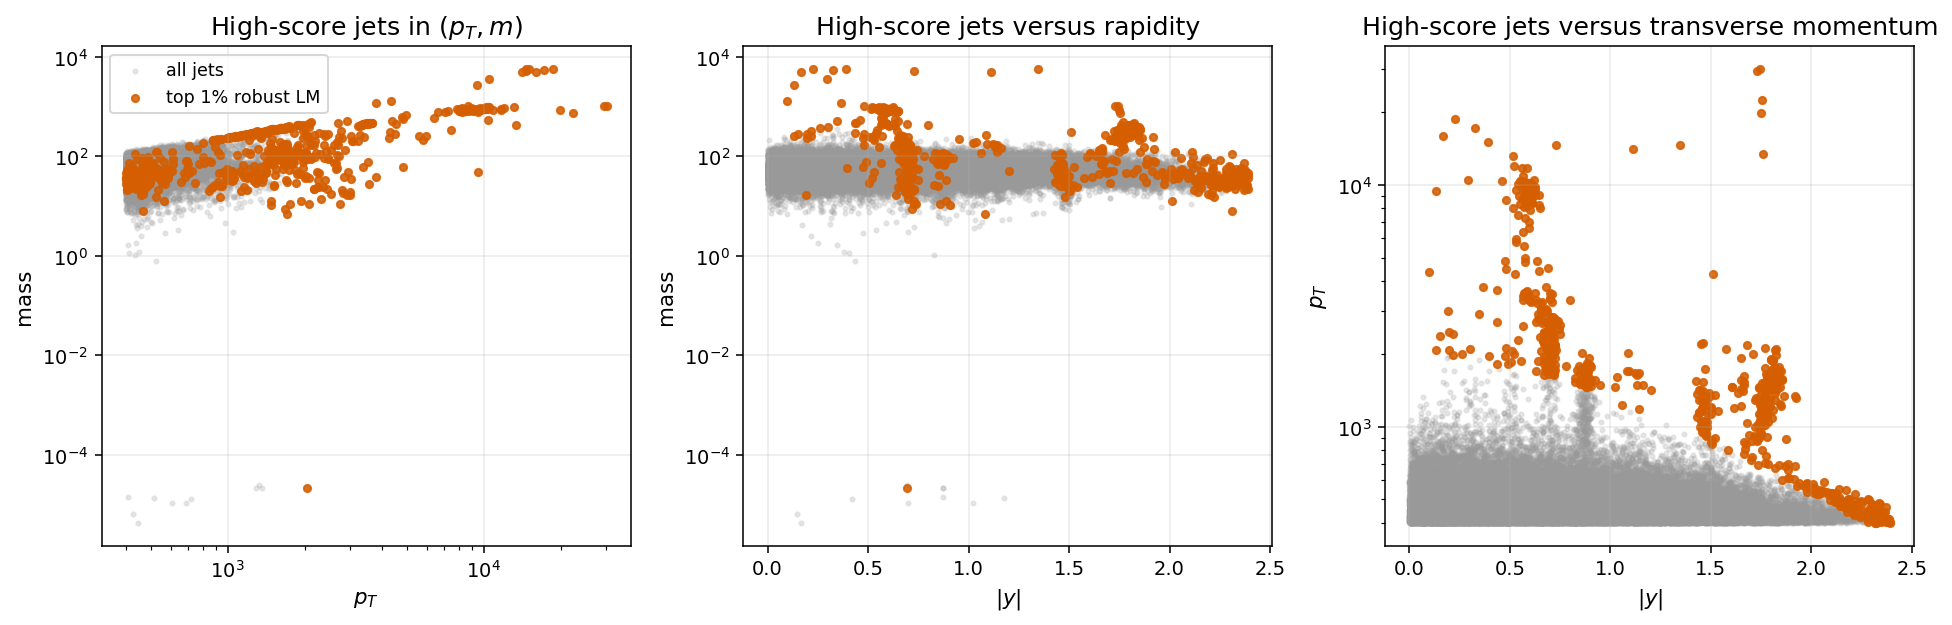

Saved: lm_realdata_clean_outputs/tables/table07_boost_ranking_stability.csv
Saved: lm_realdata_clean_outputs/tables/table07_boost_ranking_stability.tex

Table 7: real-data boost/ranking stability


,eta,score,median_relative_change,q95_relative_change,spearman_rank_correlation,top1pct_overlap
0,0.0,MCD robust LM,0.000000e+00,0.000000e+00,1.000000,1.000000
1,0.0,Naive Euclidean,6.227283e-15,1.555092e-14,1.000000,1.000000
2,0.0,Minkowski interval,2.807325e-15,2.284570e-14,1.000000,1.000000
3,0.5,MCD robust LM,2.317042e-16,6.878119e-16,1.000000,1.000000
4,0.5,Naive Euclidean,1.401749e-01,5.730997e-01,0.861003,0.936667
5,0.5,Minkowski interval,8.396466e-15,4.002464e-14,1.000000,1.000000
6,1.0,MCD robust LM,9.615706e-16,3.022089e-15,1.000000,1.000000
7,1.0,Naive Euclidean,1.647482e-01,7.233023e-01,0.796199,0.933333
8,1.0,Minkowski interval,4.390168e-15,2.531293e-14,1.000000,1.000000
9,1.5,MCD robust LM,1.122034e-14,2.713239e-14,1.000000,1.000000


Saved: lm_realdata_clean_outputs/figures/fig04_realdata_clean_boost_stability.png
Saved: lm_realdata_clean_outputs/figures/fig04_realdata_clean_boost_stability.pdf


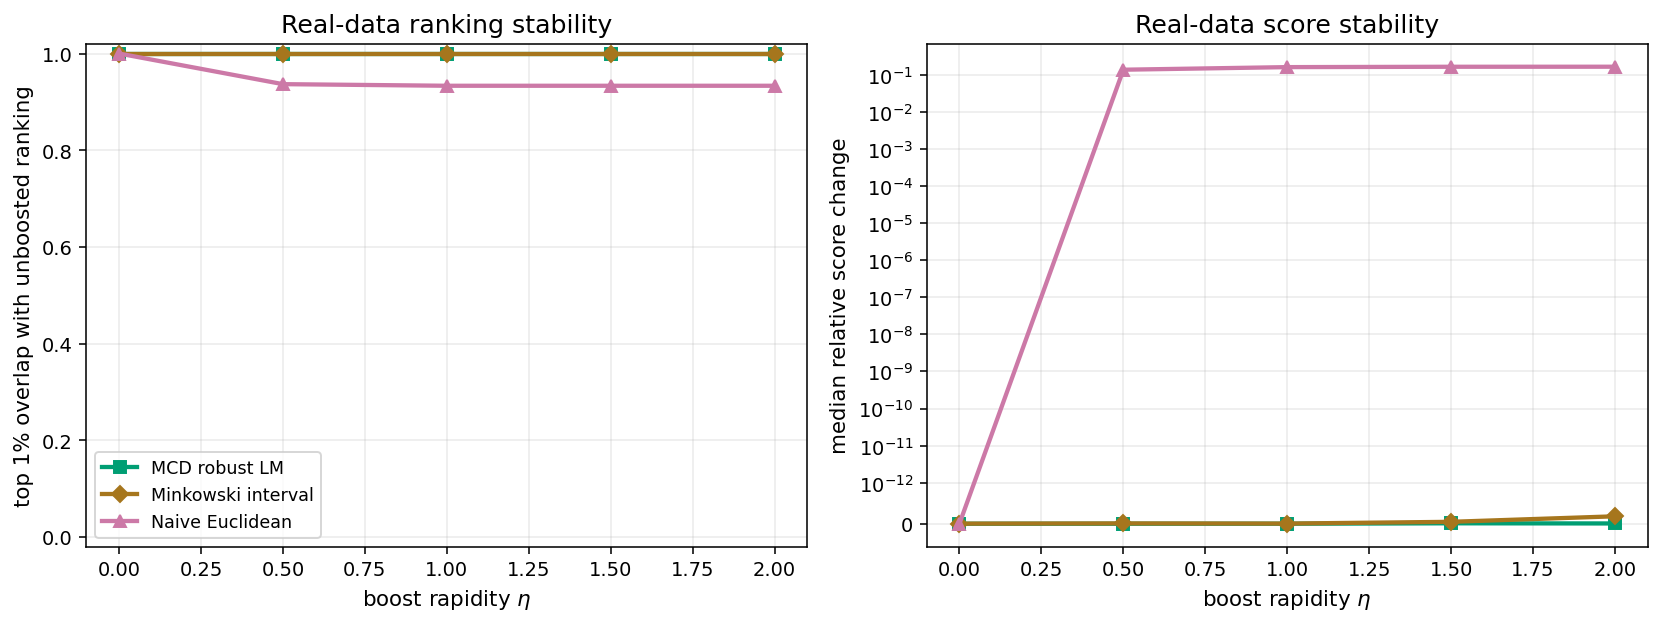

Saved: lm_realdata_clean_outputs/tables/table08_central_forward_two_sample.csv
Saved: lm_realdata_clean_outputs/tables/table08_central_forward_two_sample.tex

Table 8: central versus forward LM two-sample test


,comparison,group0,group1,n_group0,n_group1,T2,F_statistic,F_approx_pvalue,permutation_pvalue,LM_mean_separation
0,central vs forward jets,|rapidity| <= median (0.6738),|rapidity| > median (0.6738),3500,3500,1258.319212,314.444945,1.110223e-16,0.001,0.71904


/content/lm_realdata_analysis_clean.py:555: UserWarning: Two-sample analysis failed: KeyError('perm_T2')
  warnings.warn(f"Two-sample analysis failed: {repr(e)}")



Created ZIP archive: /content/lm_realdata_methodology_package/lm_realdata_clean_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from lm_realdata_analysis_clean import CLEAN_CONFIG, run_clean_realdata_analysis
results = run_clean_realdata_analysis(CLEAN_CONFIG, make_zip=True)